<a href="https://colab.research.google.com/github/Aditya-ranaaa/unsupervised-learning/blob/main/Wine_datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 45.0                 170.0   1.0010  3.00       0.45   
1                 14.0                 132.0   0.9940  3.30       0.49   
2                 30.0                  97.0   0.9951  3.26       0.44   
3                 47.0                 186.0   0.9956  3.19       0.40   
4                 47.0                 186.0   0.9956  3.19       0.40   

   alcohol  quality  
0      8.8        6  
1      9.5        6  
2     10.1        6 

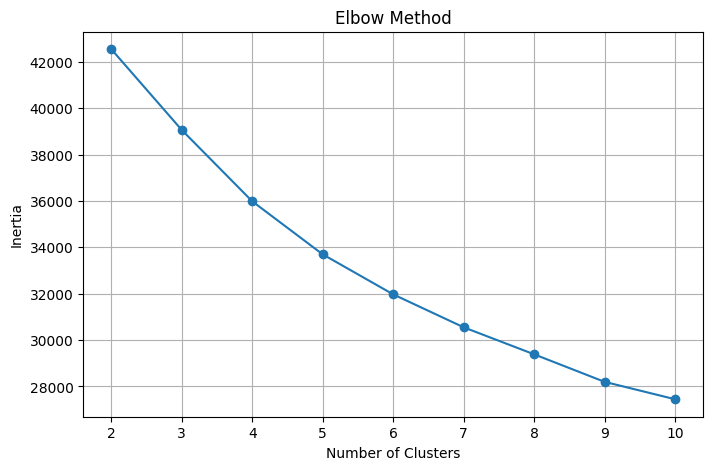

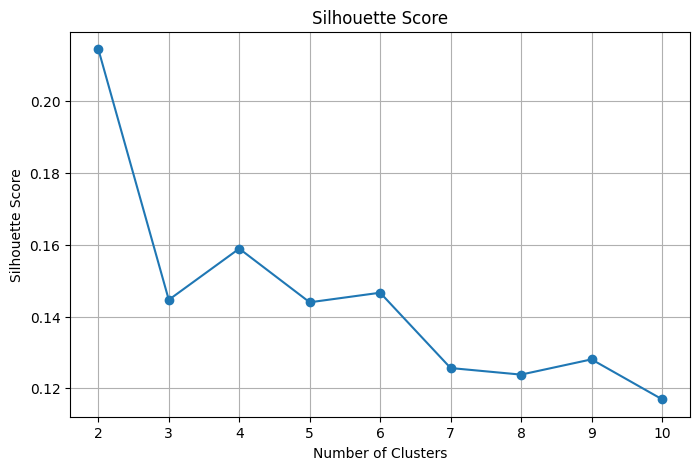

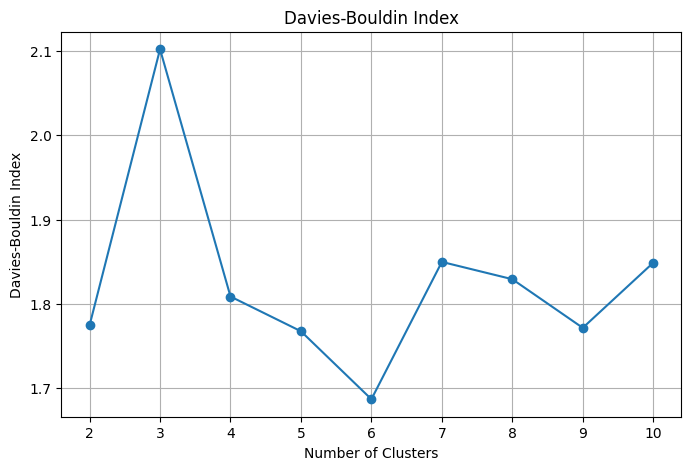

    K       Inertia  Silhouette Score  Davies-Bouldin Index
0   2  42548.668223          0.214477              1.774592
1   3  39063.293864          0.144663              2.102140
2   4  35986.920180          0.158925              1.808684
3   5  33699.044869          0.143973              1.767477
4   6  31973.440287          0.146645              1.686838
5   7  30552.664785          0.125661              1.849774
6   8  29387.273592          0.123828              1.829245
7   9  28199.407251          0.128075              1.771528
8  10  27448.757530          0.116973              1.848788
Best K according to Silhouette Score: 2
Best K according to Davies-Bouldin Index: 6
Cluster
0    1957
1    2941
Name: count, dtype: int64
         fixed acidity  volatile acidity  citric acid  residual sugar  \
Cluster                                                                 
0             7.003219          0.282966     0.362534       10.692131   
1             6.756018          0.275097   

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

df = pd.read_csv("winequality_white.csv")

print(df.head())
print(df.shape)
print(df.isnull().sum())

X = df.drop(columns=["quality"])

X = X.fillna(X.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

K = range(2, 11)

inertia = []
silhouette_scores = []
davies_bouldin_scores = []

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )
    davies_bouldin_scores.append(
        davies_bouldin_score(X_scaled, labels)
    )

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(K, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(K, davies_bouldin_scores, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Davies-Bouldin Index")
plt.title("Davies-Bouldin Index")
plt.grid()
plt.show()

results = pd.DataFrame({
    "K": K,
    "Inertia": inertia,
    "Silhouette Score": silhouette_scores,
    "Davies-Bouldin Index": davies_bouldin_scores
})

print(results)

best_silhouette_k = K[np.argmax(silhouette_scores)]
best_db_k = K[np.argmin(davies_bouldin_scores)]

print("Best K according to Silhouette Score:", best_silhouette_k)
print("Best K according to Davies-Bouldin Index:", best_db_k)

optimal_k = best_silhouette_k

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print(df["Cluster"].value_counts().sort_index())

print(df.groupby("Cluster").mean())